Final velocity after 5 strokes: 8.913 m/s


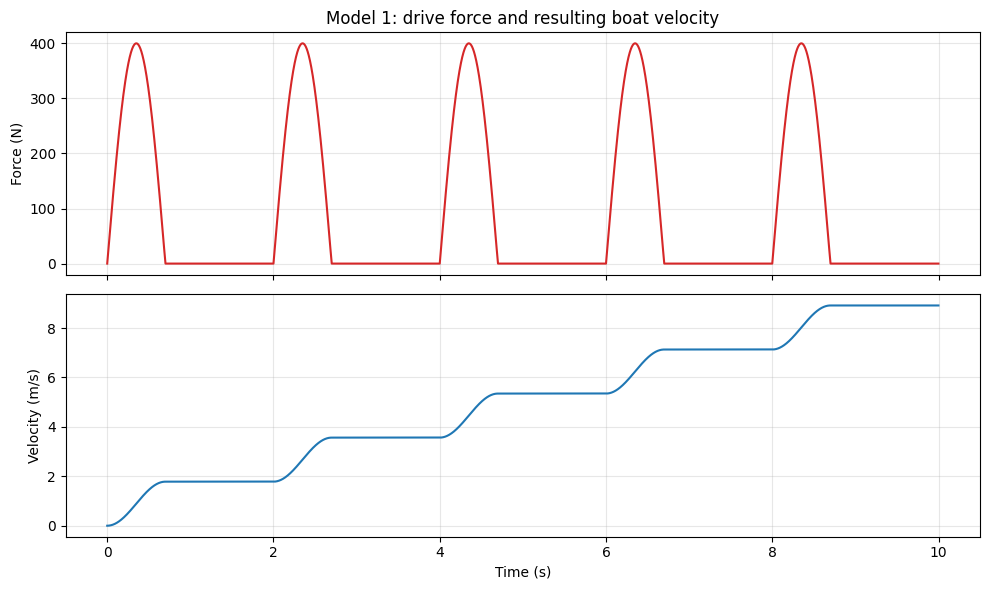

In [1]:
# ============================================================
# Model 1: drag-free, single-mass rowing boat
# Result we expect: without drag, only total impulse matters,
# so stroke SHAPE is invisible to final speed.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
m_total = 100.0      # combined mass of boat + rower(s), kg
F_max   = 400.0      # peak drive force, N
t_drive    = 0.7     # drive phase duration, s
t_recovery = 1.3     # recovery phase duration, s
t_stroke   = t_drive + t_recovery   # one full stroke, s
dt        = 0.001    # time step, s
n_strokes = 5        # number of strokes

# --- Simulation ---
total_time = n_strokes * t_stroke
times = np.arange(0, total_time, dt)
forces     = np.zeros_like(times)
velocities = np.zeros_like(times)

velocity = 0.0   # start from rest
for i, t in enumerate(times):
    t_in_stroke = t % t_stroke
    if t_in_stroke < t_drive:
        force = F_max * np.sin(np.pi * t_in_stroke / t_drive)
    else:
        force = 0.0
    acceleration = force / m_total
    velocity = velocity + acceleration * dt
    forces[i]     = force
    velocities[i] = velocity

print(f"Final velocity after {n_strokes} strokes: {velocity:.3f} m/s")

# --- Plot ---
fig, (ax_force, ax_vel) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax_force.plot(times, forces, color="tab:red")
ax_force.set_ylabel("Force (N)")
ax_force.set_title("Model 1: drive force and resulting boat velocity")
ax_force.grid(True, alpha=0.3)
ax_vel.plot(times, velocities, color="tab:blue")
ax_vel.set_ylabel("Velocity (m/s)")
ax_vel.set_xlabel("Time (s)")
ax_vel.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()